Dataset Raw 

Import thư viện

In [131]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.figsize'] = (20, 10)

1. Đọc dữ liệu và thống kê dữ liệu ban đầu

Đọc dữ liệu từ file CSV 

In [132]:
df1 = pd.read_csv('retail_sales_dataset.csv')

Kiểm tra dòng trùng lặp

In [133]:
# Kiểm tra số lượng bản ghi trùng lặp
df1.duplicated().sum()

np.int64(0)

Kiểm tra kích thước dữ liệu

In [134]:
df1.shape

(120000, 17)

Kiểm tra danh sách cột

In [135]:
# Kiểm tra các cột trong DataFrame
df1.columns

Index(['transaction_id', 'transaction_date', 'customer_id', 'customer_gender',
       'customer_age_group', 'customer_segment', 'product_id', 'product_name',
       'category', 'brand', 'quantity', 'unit_price', 'discount_pct',
       'sales_amount', 'payment_method', 'sales_channel', 'region'],
      dtype='str')

Kiểm tra kiểu dữ liệu

In [136]:
# Kiểm tra kiểu dữ liệu của các cột
df1.dtypes

transaction_id            str
transaction_date          str
customer_id               str
customer_gender           str
customer_age_group        str
customer_segment          str
product_id                str
product_name              str
category                  str
brand                     str
quantity                int64
unit_price            float64
discount_pct            int64
sales_amount          float64
payment_method            str
sales_channel             str
region                    str
dtype: object

2. Khám phá dữ liệu và tiền xử lý cơ bản

Thống kê mô tả các cột số

In [137]:
# Kiểm tra thống kê mô tả của các cột số liệu
df1.describe()

,quantity,unit_price,discount_pct,sales_amount
count,120000.000000,120000.000000,120000.000000,120000.000000
mean,1.662908,240.621785,5.496500,377.975454
std,1.014291,146.457057,8.193257,356.893357
min,1.000000,7.730000,0.000000,5.410000
25%,1.000000,102.010000,0.000000,136.860000
50%,1.000000,238.750000,0.000000,295.980000
75%,2.000000,379.000000,10.000000,461.500000
max,5.000000,493.510000,30.000000,2467.550000


Loại bỏ cột định danh không cần thiết

In [138]:
# Loại bỏ các cột ID không cần thiết cho mô hình
# KHÔNG xóa quantity vì còn dùng để tạo rolling feature qty_roll_mean_30d
df2 = df1.drop(['transaction_id', 'customer_id', 'product_id'], axis=1)
df2.shape

(120000, 14)

Kiểm tra missing value

In [139]:
# Kiểm tra các giá trị thiếu trong DataFrame sau khi loại bỏ các cột không cần thiết
df2.isnull().sum()

transaction_date      0
customer_gender       0
customer_age_group    0
customer_segment      0
product_name          0
category              0
brand                 0
quantity              0
unit_price            0
discount_pct          0
sales_amount          0
payment_method        0
sales_channel         0
region                0
dtype: int64

3. Kiểm tra và xử lý outlier

Boxplot cho sales_amount

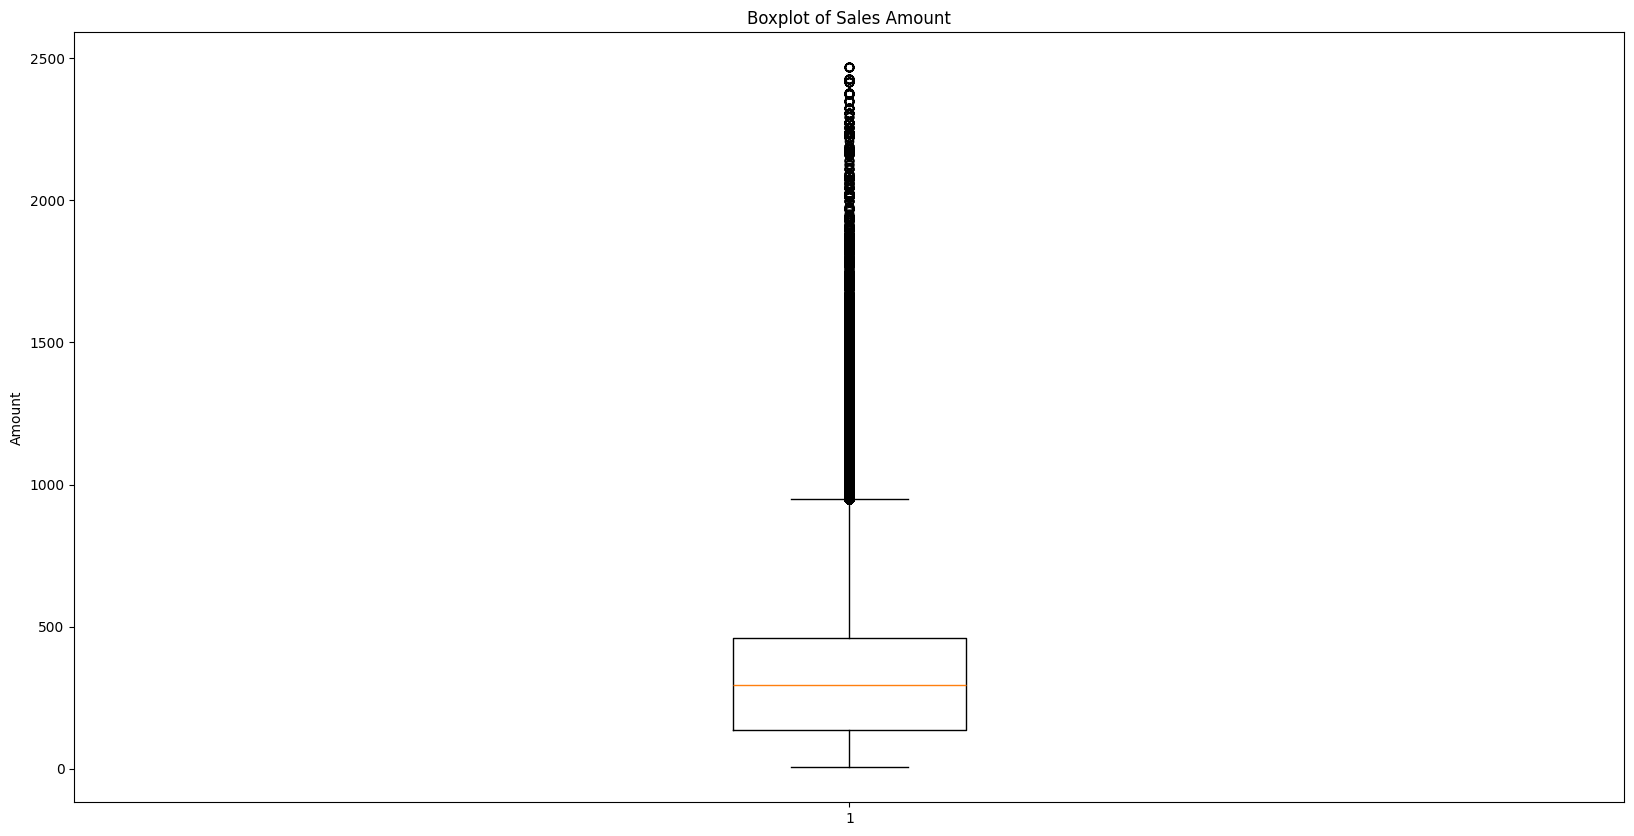

In [140]:
# Vẽ biểu đồ boxplot để kiểm tra phân phối của cột 'sales_amount'
plt.boxplot(df2['sales_amount'])
plt.title("Boxplot of Sales Amount")
plt.ylabel("Amount")
plt.show()

Lọc outlier của sales_amount bằng IQR

In [141]:
# Dùng phương pháp IQR để xác định ngưỡng cho outliers
Q1 = df2['sales_amount'].quantile(0.25)
Q3 = df2['sales_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df2[(df2.sales_amount < lower_limit) | (df2.sales_amount > upper_limit)]

,transaction_date,customer_gender,customer_age_group,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,sales_amount,payment_method,sales_channel,region
10,2024-02-27,Male,35-44,VIP,Novel,Books,Brand 3,4,379.00,0,1516.00,Cash,Online,South
21,2025-06-24,Female,25-34,Returning,Bread,Groceries,Brand 1,2,474.70,0,949.40,Cash,In-Store,East
29,2025-04-18,Male,45-54,New,Bread,Groceries,Brand 3,4,405.16,0,1620.64,Credit Card,Mobile App,Central
36,2025-08-31,Other,18-24,VIP,Towel,Home,Brand 3,3,354.89,5,1011.44,Gift Card,Mobile App,Central
46,2024-02-06,Other,55+,Returning,Storage Box,Home,Brand 1,2,493.51,0,987.02,PayPal,Online,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119967,2025-01-15,Male,25-34,New,Smartwatch,Electronics,Brand 1,4,355.50,0,1422.00,Credit Card,Online,South
119978,2025-11-29,Female,18-24,Loyal,Smartphone,Electronics,Brand 3,4,367.34,0,1469.36,Credit Card,Online,East
119981,2024-02-29,Female,25-34,Loyal,Towel,Home,Brand 2,4,408.65,5,1552.87,Credit Card,Online,North
119983,2025-06-04,Other,55+,Returning,Yoga Mat,Sports,Brand 2,3,386.78,0,1160.34,PayPal,Mobile App,West


4. Xử lý biến mục tiêu

Log transform target sales_amount

In [142]:
# Dùng phương pháp Log transformation cho sales_amount
df2['sales_amount_log'] = np.log1p(df2['sales_amount'])

Histogram trước khi log transform

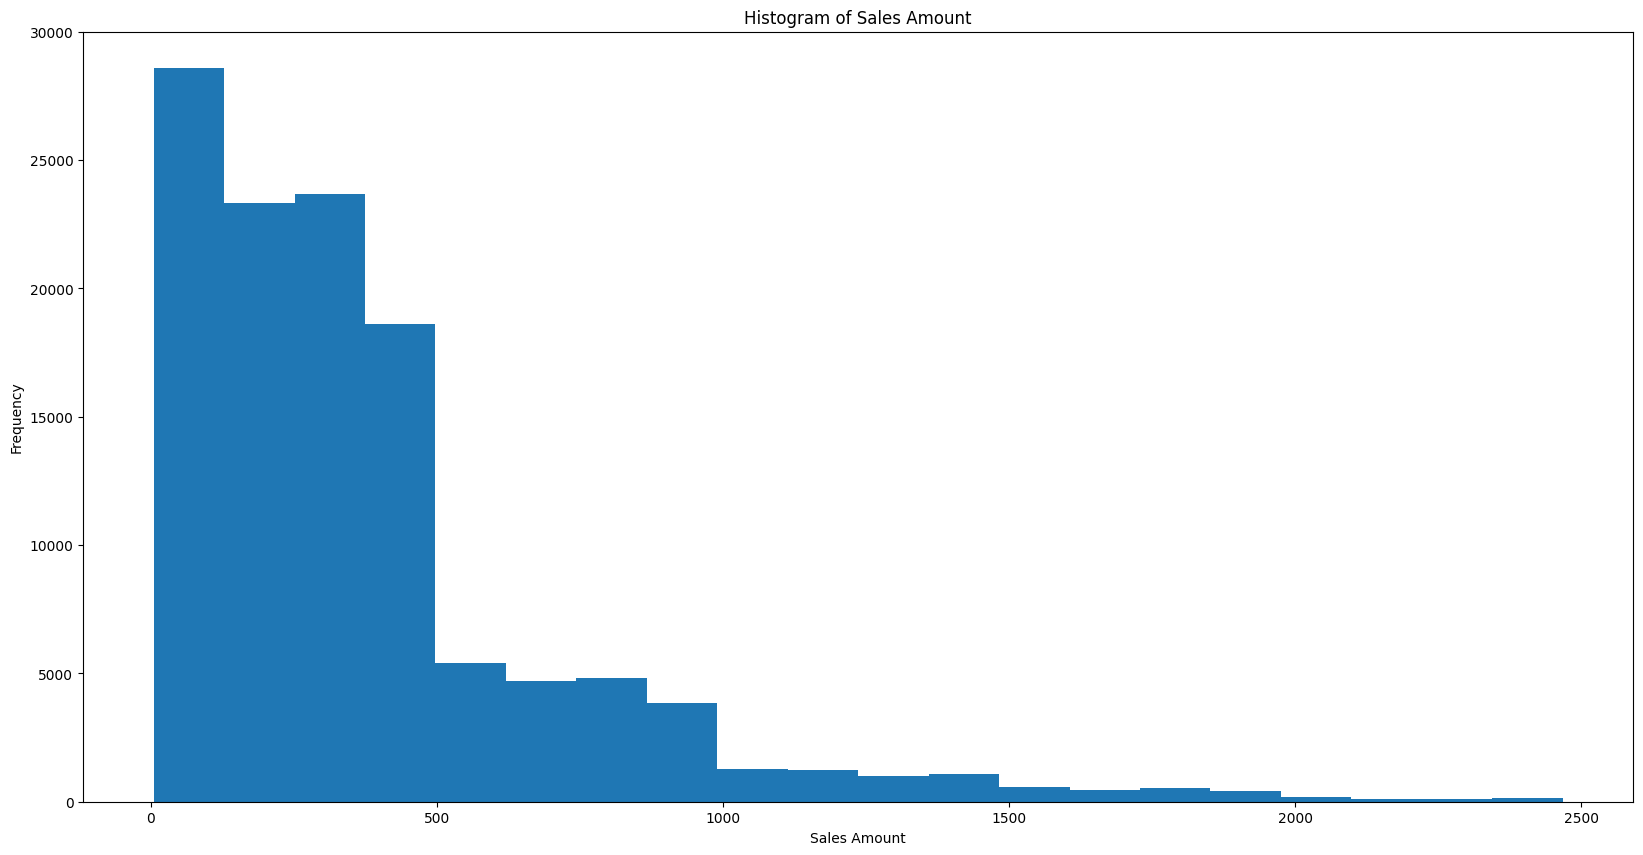

In [143]:
# Vẽ histogram của sales_amount trước khi log transform
plt.hist(df2['sales_amount'], bins=20)
plt.title("Histogram of Sales Amount")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.show()

Histogram của sales_amount_log

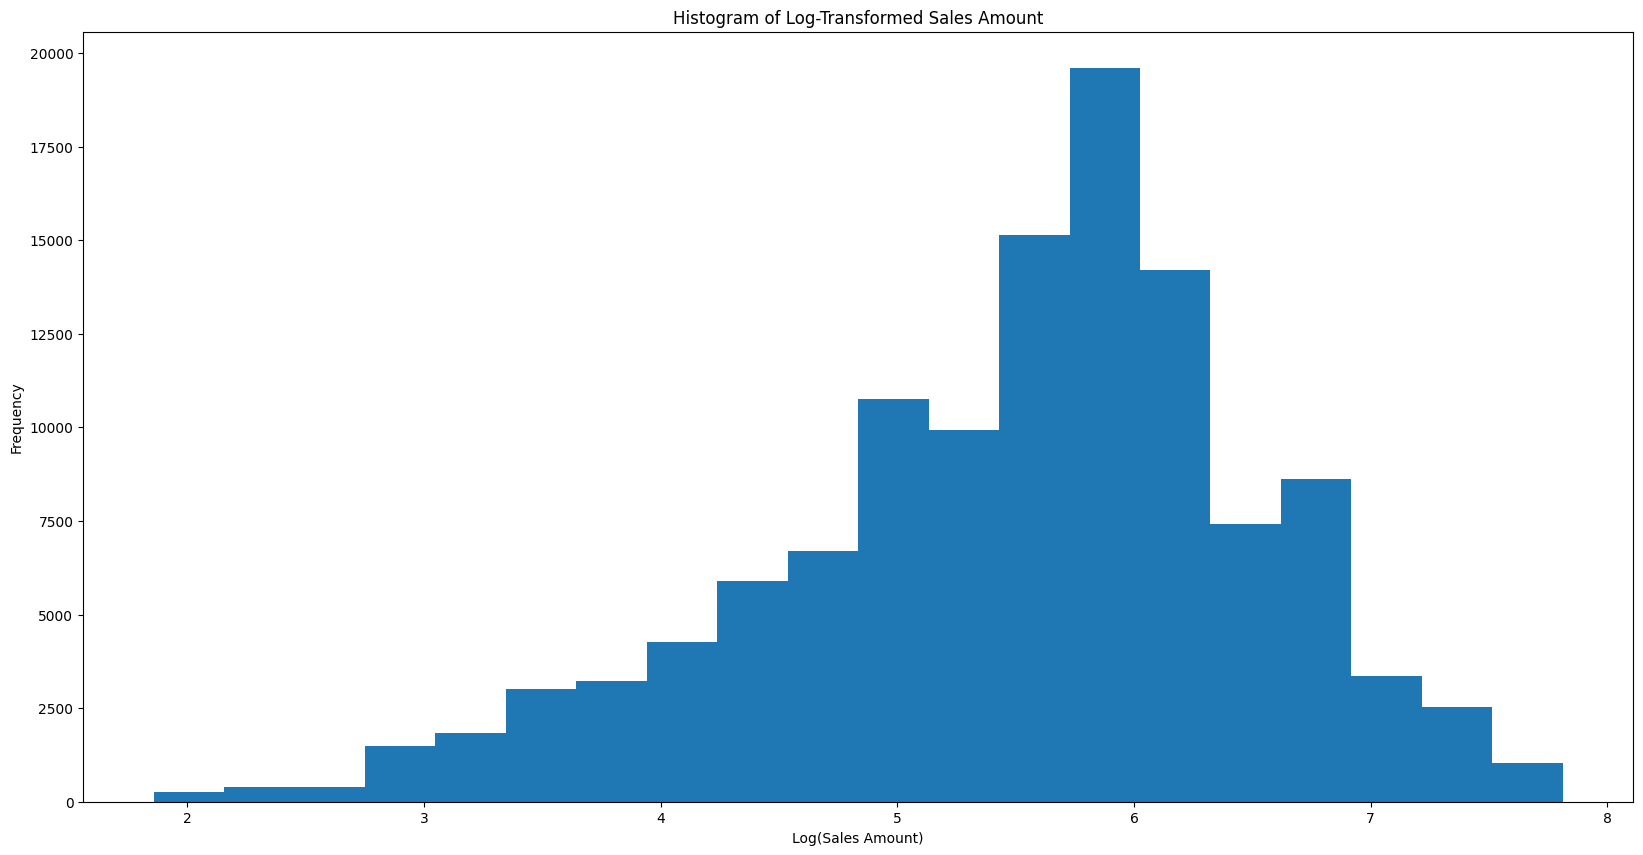

In [144]:
# Vẽ biểu đồ histogram để kiểm tra phân phối của cột 'sales_amount_log'
plt.hist(df2['sales_amount_log'], bins=20)
plt.title("Histogram of Log-Transformed Sales Amount")
plt.xlabel("Log(Sales Amount)")
plt.ylabel("Frequency")
plt.show()

Bỏ cột gốc sales_amount

In [145]:
df3 = df2.drop(['sales_amount'], axis=1)

5. Mã hóa dữ liệu phân loại 

 Tạo bản copy trước khi mã hóa

In [146]:
# Mã hóa dữ liệu
df4 = df3.copy()

Ordinal encoding cho customer_age_group

In [147]:
# Ordinary Encoding - customer_age_group
age_mapping = {
    '18-24': 0,
    '25-34': 1,
    '35-44': 2,
    '45-54': 3,
    '55+': 4
}
df4['customer_age_group_encoded'] = df4['customer_age_group'].map(age_mapping)

Kiểm tra kết quả mapping nhóm tuổi

In [148]:
print(df4['customer_age_group_encoded'].value_counts())
print("Số lượng dòng bị lỗi map:", df4['customer_age_group_encoded'].isna().sum())

customer_age_group_encoded
2    24196
4    24078
0    23941
3    23919
1    23866
Name: count, dtype: int64
Số lượng dòng bị lỗi map: 0


Xóa cột tuổi dạng chữ

In [149]:
df5 = df4.drop(['customer_age_group'], axis=1)
df5.head()

,transaction_date,customer_gender,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,payment_method,sales_channel,region,sales_amount_log,customer_age_group_encoded
0,2024-04-24,Other,Returning,Dumbbells,Sports,Brand 1,2,313.53,20,Debit Card,Online,North,6.219894,2
1,2025-07-12,Other,New,Running Shoes,Sports,Brand 3,1,366.16,0,Credit Card,Online,South,5.905798,3
2,2025-06-01,Male,Returning,Sneakers,Clothing,Brand 3,1,27.99,0,Gift Card,In-Store,South,3.366951,4
3,2025-08-26,Male,VIP,Sunscreen,Beauty,Brand 1,2,102.01,15,Cash,In-Store,South,5.161466,1
4,2024-12-10,Male,New,Sneakers,Clothing,Brand 1,1,259.55,0,Cash,In-Store,Central,5.562795,3


Chuẩn bị danh sách cột phân loại để one-hot encoding sau khi split

In [150]:
# Tạo bản copy sau khi đã encode customer_age_group
# One-hot encoding sẽ làm SAU KHI chia train/test để tránh data leakage
df6 = df5.copy()

ohe_columns = [
    'customer_gender',
    'customer_segment',
    'product_name',
    'category',
    'brand',
    'payment_method',
    'sales_channel',
    'region'
]

df6.head()

,transaction_date,customer_gender,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,payment_method,sales_channel,region,sales_amount_log,customer_age_group_encoded
0,2024-04-24,Other,Returning,Dumbbells,Sports,Brand 1,2,313.53,20,Debit Card,Online,North,6.219894,2
1,2025-07-12,Other,New,Running Shoes,Sports,Brand 3,1,366.16,0,Credit Card,Online,South,5.905798,3
2,2025-06-01,Male,Returning,Sneakers,Clothing,Brand 3,1,27.99,0,Gift Card,In-Store,South,3.366951,4
3,2025-08-26,Male,VIP,Sunscreen,Beauty,Brand 1,2,102.01,15,Cash,In-Store,South,5.161466,1
4,2024-12-10,Male,New,Sneakers,Clothing,Brand 1,1,259.55,0,Cash,In-Store,Central,5.562795,3


Kiểm tra kích thước dữ liệu trước khi split

In [151]:
df6.shape

(120000, 14)

Xem danh sách cột trước khi split

In [152]:
df6.columns

Index(['transaction_date', 'customer_gender', 'customer_segment',
       'product_name', 'category', 'brand', 'quantity', 'unit_price',
       'discount_pct', 'payment_method', 'sales_channel', 'region',
       'sales_amount_log', 'customer_age_group_encoded'],
      dtype='str')

6. Feature engineering

Tạo cột năm, tháng, ngày, thứ trong tuần

In [153]:
# Chuyển transaction_date sang datetime
df6['transaction_date'] = pd.to_datetime(df6['transaction_date'])

# Tạo feature thời gian trước khi split
df6['transaction_year'] = df6['transaction_date'].dt.year
df6['transaction_month'] = df6['transaction_date'].dt.month
df6['transaction_day'] = df6['transaction_date'].dt.day
df6['transaction_dayofweek'] = df6['transaction_date'].dt.dayofweek

Xem dữ liệu sau khi thêm đặc trưng thời gian

In [154]:
df6.head()

,transaction_date,customer_gender,customer_segment,product_name,category,brand,quantity,unit_price,discount_pct,payment_method,sales_channel,region,sales_amount_log,customer_age_group_encoded,transaction_year,transaction_month,transaction_day,transaction_dayofweek
0,2024-04-24,Other,Returning,Dumbbells,Sports,Brand 1,2,313.53,20,Debit Card,Online,North,6.219894,2,2024,4,24,2
1,2025-07-12,Other,New,Running Shoes,Sports,Brand 3,1,366.16,0,Credit Card,Online,South,5.905798,3,2025,7,12,5
2,2025-06-01,Male,Returning,Sneakers,Clothing,Brand 3,1,27.99,0,Gift Card,In-Store,South,3.366951,4,2025,6,1,6
3,2025-08-26,Male,VIP,Sunscreen,Beauty,Brand 1,2,102.01,15,Cash,In-Store,South,5.161466,1,2025,8,26,1
4,2024-12-10,Male,New,Sneakers,Clothing,Brand 1,1,259.55,0,Cash,In-Store,Central,5.562795,3,2024,12,10,1


7. Chia train/test, tạo rolling feature, encoding, scaling và xuất dữ liệu

Chia tập train/test theo trục thời gian

In [155]:
# Chia train/test theo thời gian
# 80% dữ liệu cũ làm train, 20% dữ liệu mới làm test

df_chronological = df6.sort_values('transaction_date').reset_index(drop=True)

split_point = int(len(df_chronological) * 0.8)

train_data = df_chronological.iloc[:split_point].copy()
test_data = df_chronological.iloc[split_point:].copy()

print("Train shape trước rolling:", train_data.shape)
print("Test shape trước rolling:", test_data.shape)

Train shape trước rolling: (96000, 18)
Test shape trước rolling: (24000, 18)


Tạo rolling feature sau khi split

Tạo `qty_roll_mean_30d` sau khi đã chia train/test để tránh dùng thông tin tương lai.

In [164]:
# Tạo rolling mean 30 ngày sau khi split
# Test chỉ dùng lịch sử quantity từ train, không dùng quantity của chính test

train_data = train_data.copy().reset_index(drop=True)
test_data = test_data.copy().reset_index(drop=True)

train_data["_set"] = "train"
test_data["_set"] = "test"

train_data["_order"] = train_data.index
test_data["_order"] = test_data.index

all_data = pd.concat([train_data, test_data], ignore_index=True)
all_data = all_data.sort_values(["product_name", "transaction_date"]).reset_index(drop=True)

all_data["quantity_for_rolling"] = np.where(
    all_data["_set"] == "train",
    all_data["quantity"],
    np.nan
)

roll = (
    all_data
    .set_index("transaction_date")
    .groupby("product_name", sort=False)["quantity_for_rolling"]
    .rolling("30D", closed="left")
    .mean()
)

all_data["qty_roll_mean_30d"] = roll.to_numpy()
# Kiểm tra NaN sau khi tạo rolling feature, trước khi fill
nan_count = all_data["qty_roll_mean_30d"].isna().sum()
nan_percent = all_data["qty_roll_mean_30d"].isna().mean() * 100

print("Số giá trị NaN trong qty_roll_mean_30d:", nan_count)
print("Tỷ lệ NaN (%):", round(nan_percent, 2))

product_mean_qty = train_data.groupby("product_name")["quantity"].mean()
global_mean_qty = train_data["quantity"].mean()

all_data["qty_roll_mean_30d"] = all_data["qty_roll_mean_30d"].fillna(
    all_data["product_name"].map(product_mean_qty)
)

all_data["qty_roll_mean_30d"] = all_data["qty_roll_mean_30d"].fillna(global_mean_qty)

train_data = (
    all_data[all_data["_set"] == "train"]
    .sort_values("_order")
    .drop(columns=["_set", "_order", "quantity_for_rolling"])
    .reset_index(drop=True)
)

test_data = (
    all_data[all_data["_set"] == "test"]
    .sort_values("_order")
    .drop(columns=["_set", "_order", "quantity_for_rolling"])
    .reset_index(drop=True)
)

print("Missing rolling train:", train_data["qty_roll_mean_30d"].isnull().sum())
print("Missing rolling test:", test_data["qty_roll_mean_30d"].isnull().sum())
print("Train shape sau rolling:", train_data.shape)
print("Test shape sau rolling:", test_data.shape)

Số giá trị NaN trong qty_roll_mean_30d: 19087
Tỷ lệ NaN (%): 15.91
Missing rolling train: 0
Missing rolling test: 0
Train shape sau rolling: (96000, 19)
Test shape sau rolling: (24000, 19)


One-hot encoding sau khi split

In [158]:
# One-hot encoding sau khi split
# Drop các cột không dùng trực tiếp cho model

drop_cols = [
    'transaction_date',
    'quantity'
]

train_model = train_data.drop(columns=drop_cols, errors='ignore')
test_model = test_data.drop(columns=drop_cols, errors='ignore')

# Chỉ lấy các cột categorical đang thật sự tồn tại trong dữ liệu
ohe_cols_available = [col for col in ohe_columns if col in train_model.columns]

train_encoded = pd.get_dummies(train_model, columns=ohe_cols_available, dtype=int)
test_encoded = pd.get_dummies(test_model, columns=ohe_cols_available, dtype=int)

# Căn chỉnh cột test giống hệt train
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

print("Train encoded shape:", train_encoded.shape)
print("Test encoded shape:", test_encoded.shape)

Train encoded shape: (96000, 80)
Test encoded shape: (24000, 80)


In [159]:
# Chỉ scale: unit_price, qty_roll_mean_30d

from sklearn.preprocessing import StandardScaler

numeric_cols = [
    'unit_price',
    'qty_roll_mean_30d'
]

scaler = StandardScaler()

# Fit scaler trên train, transform test
train_encoded[numeric_cols] = scaler.fit_transform(train_encoded[numeric_cols])
test_encoded[numeric_cols] = scaler.transform(test_encoded[numeric_cols])

print("Đã chuẩn hóa các cột:", numeric_cols)
print(train_encoded[numeric_cols].describe().round(2))

Đã chuẩn hóa các cột: ['unit_price', 'qty_roll_mean_30d']
       unit_price  qty_roll_mean_30d
count    96000.00           96000.00
mean        -0.00               0.00
std          1.00               1.00
min         -1.59              -6.71
25%         -0.94              -0.66
50%         -0.02              -0.03
75%          0.94               0.62
max          1.72               8.49


In [160]:
# Kiểm tra thống kê các cột số sau scaling trên train
print(train_encoded[numeric_cols].describe().round(2))

       unit_price  qty_roll_mean_30d
count    96000.00           96000.00
mean        -0.00               0.00
std          1.00               1.00
min         -1.59              -6.71
25%         -0.94              -0.66
50%         -0.02              -0.03
75%          0.94               0.62
max          1.72               8.49


In [161]:
# Kiểm tra thống kê các cột số sau scaling trên test
print(test_encoded[numeric_cols].describe().round(2))

       unit_price  qty_roll_mean_30d
count    24000.00           24000.00
mean        -0.01               0.03
std          1.00               1.18
min         -1.59              -6.71
25%         -0.95              -0.21
50%         -0.02              -0.00
75%          0.94               0.14
max          1.72              33.84


Lưu file train/test sau xử lý

In [162]:
train_encoded.to_csv(
    'retail_train_80.csv',
    index=False
)

test_encoded.to_csv(
    'retail_test_20.csv',
    index=False
)

print("Đã lưu retail_train_80.csv")
print("Đã lưu retail_test_20.csv")
print("Train shape:", train_encoded.shape)
print("Test shape:", test_encoded.shape)

Đã lưu retail_train_80.csv
Đã lưu retail_test_20.csv
Train shape: (96000, 80)
Test shape: (24000, 80)


Xem dữ liệu cuối cùng sau khi xử lý

In [163]:
train_encoded.head()

,unit_price,discount_pct,sales_amount_log,customer_age_group_encoded,transaction_year,transaction_month,transaction_day,transaction_dayofweek,qty_roll_mean_30d,customer_gender_Female,...,payment_method_Gift Card,payment_method_PayPal,sales_channel_In-Store,sales_channel_Mobile App,sales_channel_Online,region_Central,region_East,region_North,region_South,region_West
0,-0.345401,20,5.032527,4,2024,1,1,0,0.136990,0,...,0,0,1,0,0,0,0,1,0,0
1,0.543162,0,5.773277,3,2024,1,1,0,-0.017313,0,...,0,0,0,0,1,0,1,0,0,0
2,-1.280785,0,3.995445,3,2024,1,1,0,0.113202,0,...,0,0,0,1,0,0,1,0,0,0
3,-1.280785,0,3.995445,1,2024,1,1,0,0.113202,0,...,1,0,0,1,0,0,0,1,0,0
4,0.998194,0,5.961675,0,2024,1,1,0,-0.085984,1,...,0,0,1,0,0,1,0,0,0,0
